In [2]:
import numpy as np
from scipy.stats import spearmanr


def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

In [2]:
# lunarlander

supervised_regret = [20, 0, 248, 0, 20]
q_regret = [0, 20.2, 0, 6, 3.6]
hinge_regret = [3.5, 3.7, 0, 6, 0]
kendall_regret = [0, 0, 0, 0, 3.6]
listnet_regret = [6, 6, 6, 6, 6]


regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 57.60 ± 42.76
Q-based     : 5.96 ± 3.34
Hinge       : 2.64 ± 1.04
Kendall     : 0.72 ± 0.64
ListNet     : 6.00 ± 0.00


In [3]:

# True ranking
true_ranking = [5, 3, 4, 2, 1]

# All rankings by estimator and seed
supervised_rankings = [
    [2, 3, 5, 1, 4],  # seed 0
    [5, 4, 2, 3, 1],  # seed 1
    [1, 5, 3, 4, 2],  # seed 2
    [5, 3, 2, 1, 4],  # seed 3
    [2, 5, 3, 4, 1],  # seed 4
]

q_rankings = [
    [5, 3, 4, 2, 1],  # seed 0
    [2, 5, 3, 4, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [3, 5, 4, 2, 1],  # seed 4
]

hinge_rankings = [
    [3, 5, 4, 2, 1],  # seed 0
    [3, 2, 5, 4, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [5, 3, 4, 2, 1],  # seed 4
]

kendall_rankings = [
    [5, 4, 3, 2, 1],  # seed 0
    [5, 3, 4, 2, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [5, 4, 3, 2, 1],  # seed 3
    [3, 4, 5, 2, 1],  # seed 4
]

listnet_rankings = [
    [4, 5, 3, 2, 1],  # seed 0
    [4, 5, 2, 3, 1],  # seed 1
    [4, 3, 5, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [4, 3, 5, 2, 1],  # seed 4
]

# Calculate average Spearman correlation for each estimator
def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.160 ± 0.149
Q-based     : 0.660 ± 0.140
Hinge       : 0.740 ± 0.083
Kendall     : 0.880 ± 0.044
ListNet     : 0.740 ± 0.067


In [4]:
# lunarlander, nll loss, lambda 0.5, patience 50

supervised_regret = [251, 251, 6, 3.7, 20]
q_regret = [6,6,6,6,6]
hinge_regret = [0, 0, 0, 6, 3.7]
kendall_regret = [0, 0, 0, 0, 20]
listnet_regret = [0, 20, 20, 20, 3.7]

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 106.34 ± 52.88
Q-based     : 6.00 ± 0.00
Hinge       : 1.94 ± 1.11
Kendall     : 4.00 ± 3.58
ListNet     : 12.74 ± 4.01


In [ ]:
from scipy.stats import spearmanr

# True ranking
true_ranking = [5, 3, 4, 2, 1, 0]

supervised_rankings = [
    [4,3,5,2,1,0],  
    [3,5,2,1,4,0], 
    [2,1,4,5,3,0],  
    [1,4,5,2,3,0],  
    [1,4,5,2,3,0],  
]

q_rankings = [
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],   
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],  
]

hinge_rankings = [
    [5,3,2,4,1,0],  
    [4,5,2,3,1,0],  
    [5,4,3,2,1,0],  
    [5,4,3,2,1,0],  
    [3,4,5,2,1,0],  
]

kendall_rankings = [
    [5,4,2,3,1,0],  
    [5,2,3,4,1,0],  
    [5,2,3,4,1,0],  
    [5,3,4,2,1,0],  
    [3,2,4,5,1,0],  
]

listnet_rankings = [
    [5,4,3,2,1,0],  
    [2,4,5,3,1,0],  
    [3,2,5,4,1,0],  
    [2,4,3,5,1,0],  
    [2,5,1,4,3,0],  
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.417 ± 0.112
Q-based     : 0.829 ± 0.000
Hinge       : 0.897 ± 0.041
Kendall     : 0.783 ± 0.075
ListNet     : 0.600 ± 0.096


In [6]:
# lunarlander, mse loss, lambda 0.1, patience 200

supervised_regret = [6.3, 6.3, 70, 1.1, 1.1]
kendall_regret = [6.3, 0, 0, 0, 0]

regrets = {
    'Supervised': supervised_regret,
    'Kendall': kendall_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 16.96 ± 11.91
Kendall     : 1.26 ± 1.13


In [8]:
from scipy.stats import spearmanr

# True ranking
true_ranking = [5, 4, 3, 2, 1]

supervised_rankings = [
    [3,2,4,5,1],  
    [3,4,5,2,1], 
    [4,3,2,1,5],  
    [2,5,4,3,1],  
    [4,3,5,2,1],  
]

kendall_rankings = [
    [4,3,2,5,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.360 ± 0.122
Kendall     : 0.880 ± 0.107


In [15]:
# pendulum

# 75.3

supervised_regret = [0.64,0.23,0.27,0.3, 0.35]
q_regret = [0.05, 0.23, 0.27, 0.14, 0.09]
hinge_regret = [0.05, 0.23, 0.05, 0.58, 0.09]
kendall_regret = [0.05, 0.64, 0.05, 0.14, 0.09]
listnet_regret = [0.05, 0.64, 0,0, 0.09]  

In [16]:
def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 0.36 ± 0.07
Q-based     : 0.16 ± 0.04
Hinge       : 0.20 ± 0.09
Kendall     : 0.19 ± 0.10
ListNet     : 0.16 ± 0.11


In [17]:
true_ranking = [5,4,3,2,1,0]

supervised_rankings = [
    [2,4,3,5,1,0],
    [3,1,5,4,2,0],
    [3,2,4,5,1,0],
    [3,2,4,5,1,0],
    [3,4,2,5,1,0]
]
q_rankings = [
    [3,4,5,2,1,0],
    [3,4,2,5,1,0],
    [3,4,5,2,1,0],
    [4,2,5,3,1,0],
    [4,3,2,5,1,0]
]
hinge_rankings = [
    [4,5,2,3,1,0],
    [3,4,2,5,1,0],
    [4,5,3,2,1,0],
    [2,4,5,1,3,0],
    [4,3,5,2,1,0]
]
kendall_rankings = [
    [4,5,3,2,1,0],
    [2,4,5,1,3,0],
    [4,3,5,2,1,0],
    [4,5,3,2,1,0],
    [4,5,3,2,1,0]
]
listnet_rankings = [
    [4,3,5,2,1,0],
    [2,3,4,5,1,0],
    [5,4,3,2,1,0],
    [5,3,4,2,1,0],
    [4,5,3,1,2,0]
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.486 ± 0.032
Q-based     : 0.703 ± 0.030
Hinge       : 0.749 ± 0.079
Kendall     : 0.829 ± 0.079
ListNet     : 0.817 ± 0.091


In [28]:
# pendulum nll


supervised_regret = [0.3, 0.6, 0, 0.14]
q_regret = [0, 0, 0.14, 0.14, 0.6]
hinge_regret = [0,0.14,0.3,0.3,0]
kendall_regret = [0, 0, 0.14, 0, 0]
listnet_regret = [0,0.3,0.14,0.3,0]

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 0.26 ± 0.11
Q-based     : 0.18 ± 0.10
Hinge       : 0.15 ± 0.06
Kendall     : 0.03 ± 0.03
ListNet     : 0.15 ± 0.06


In [29]:
true_ranking = [5,4,3,2,1,0]

supervised_rankings = [
    [3,5,4,2,1,0],
    [5,2,3,4,1,0],
    [2,3,4,5,1,0],
    [4,1,5,3,2,0]
]
q_rankings = [
    [5,4,3,2,1,0],
    [5,3,4,2,1,0],
    [4,5,3,2,1,0],
    [4,3,5,2,1,0],
    [2,3,5,4,1,0]
]
hinge_rankings = [
    [4,3,5,2,1,0],
    [5,3,4,2,1,0],
    [3,2,4,5,1,0],
    [3,5,2,4,1,0],
    [5,3,1,2,4,0]
]
kendall_rankings = [
    [5,3,2,4,1,0],
    [5,3,4,2,1,0],
    [4,5,3,2,1,0],
    [5,4,3,2,1,0],
    [5,3,4,2,1,0]
]
listnet_rankings = [
    [5,4,3,1,2,0],
    [3,5,4,1,2,0],
    [3,4,2,5,1,0],
    [4,3,5,1,2,0],
    [5,4,3,2,1,0]
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.643 ± 0.082
Q-based     : 0.840 ± 0.083
Hinge       : 0.714 ± 0.072
Kendall     : 0.931 ± 0.025
ListNet     : 0.817 ± 0.063


In [4]:
#pendulum mse

supervised_regret = [0.02, 0, 0.73, 0.14, 0.04, 0.16]
q_regret = [0, 0.04, 0.02, 0, 0.02, 0]
hinge_regret = []
kendall_regret = [0, 0, 0.08, 0.65, 0.16]
listnet_regret = []

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    #'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    #'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 0.18 ± 0.10
Q-based     : 0.01 ± 0.01
Kendall     : 0.18 ± 0.11


In [6]:
true_ranking = [5,4,3,2,1,0]

supervised_rankings = [
    [5,3,4,1,2,0],
    [5,4,2,3,1,0],
    [2,3,1,5,4,0],
    [3,5,4,1,2,0],
    [4,2,3,5,1,0],
    [3,2,1,4,5,0]
]
kendall_rankings = [
    [5,4,3,2,1,0],
    [5,3,4,2,1,0],
    [2,5,3,4,1,0],
    [5,4,2,3,1,0],
    [5,3,2,1,4,0],
    [3,2,5,4,1,0]
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    #'Q-based': q_rankings,
    #'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    #'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.562 ± 0.144
Kendall     : 0.781 ± 0.075


In [ ]:
#ghaffari cancer (continuous) nll base loss (seeds 26-30)

# lunarlander

supervised_regret = [0,0,0,0,65.7]
#q_regret = []
#hinge_regret = [3.5, 3.7, 0, 6, 0]
kendall_regret = [0,0,0,0,0]
#listnet_regret = [6, 6, 6, 6, 6]


regrets = {
    'Supervised': supervised_regret,
#    'Q-based': q_regret,
#    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
#    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 13.14 ± 11.75
Kendall     : 0.00 ± 0.00


In [9]:
true_ranking = [5,4,3,2,1]

supervised_rankings = [
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [1,2,5,3,4],
    [5,4,3,2,1],
]
kendall_rankings = [
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.660 ± 0.304
Kendall     : 1.000 ± 0.000


In [8]:
#ghaffari cancer (continuous) mse base loss (seeds 21-25)

supervised_regret = [59.6, 23.5, 0, 0, 59.3]
#q_regret = []
hinge_regret = [13,0,0,0,0]
kendall_regret = [27.5, 0, 0, 0, 0]
listnet_regret = [27.5, 0,0,0,0]


regrets = {
    'Supervised': supervised_regret,
#    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 28.48 ± 11.94
Hinge       : 2.60 ± 2.33
Kendall     : 5.50 ± 4.92
ListNet     : 5.50 ± 4.92


In [11]:
true_ranking = [5,4,3,2,1]

supervised_rankings = [
    [3,4,2,5,1],
    [2,5,3,4,1],
    [5,3,4,2,1],
    [5,4,3,2,1],
    [2,5,4,3,1],
]
kendall_rankings = [
    [4,2,5,3,1],
    [5,3,4,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,3,4,2,1],
]
listnet_rankings = [
    [3,4,5,2,1],
    [5,4,2,3,1],
    [5,4,3,2,1],
    [5,3,4,2,1],
    [5,4,3,2,1],
]
hinge_rankings = [
    [5,4,2,3,1],
    [4,2,3,5,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,2,3,1],
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
    'Hinge': hinge_rankings,
    'Listnet': listnet_rankings
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.580 ± 0.137
Kendall     : 0.860 ± 0.083
Hinge       : 0.820 ± 0.118
Listnet     : 0.880 ± 0.066


In [8]:
true_ranking = [5,4,3,2,1]

# testing different lamdas

kendall_rankings = [
    [5,4,3,1,2],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,3,4,2,1],
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.580 ± 0.137
Kendall     : 0.960 ± 0.022


In [2]:
#different lambda rank mse in cancer (mse base)
supervised_train_mse = [0.237, 0.242, 0.256, 0.343, 0.396]
supervised_test_mse = [0.278, 0.185, 0.162, 0.284, 0.264]

kendell_01_train_mse = [0.236, 0.240, 0.251, 0.335, 0.387]
kendell_01_test_mse = [0.280, 0.188, 0.160, 0.275, 0.259]

kendell_02_train_mse = [0.232, 0.442, 0.246, 0.338, 0.373]
kendell_02_test_mse = [0.279, 0.292, 0.153, 0.275, 0.253]

kendell_03_train_mse = [0.241, 0.249, 0.254, 0.333, 0.396]
kendell_03_test_mse = [0.285, 0.189, 0.161, 0.276, 0.262]

kendell_04_train_mse = [0.234, 0.238, 0.254, 0.336, 0.397]
kendell_04_test_mse = [0.278, 0.188, 0.159, 0.278, 0.256]

kendell_05_train_mse = [0.251, 0.277, 0.242, 0.387, 0.429]
kendell_05_test_mse = [0.301, 0.200, 0.155, 0.315, 0.288]

kendell_06_train_mse = [0.237, 0.444, 0.273, 0.340, 0.422]
kendell_06_test_mse = [0.285, 0.292, 0.174, 0.280, 0.281]

kendell_07_train_mse = [0.384, 0.280, 0.264, 0.349, 0.422] #not done the 5th
kendell_07_test_mse = [0.401, 0.203, 0.162, 0.293, 0.281]

kendell_08_train_mse = [0.259, 0.278, 0.237, 0.355, 0.452] 
kendell_08_test_mse = [0.307, 0.204, 0.158, 0.293, 0.310]

kendell_09_train_mse = [0.370, 0.247, 0.358, 0.348, 0.553] 
kendell_09_test_mse = [0.386, 0.189, 0.259, 0.288, 0.392]

kendell_1_train_mse = [0.414, 0.462, 0.404, 0.579, 0.638] 
kendell_1_test_mse = [0.427, 0.305, 0.286, 0.413, 0.454]

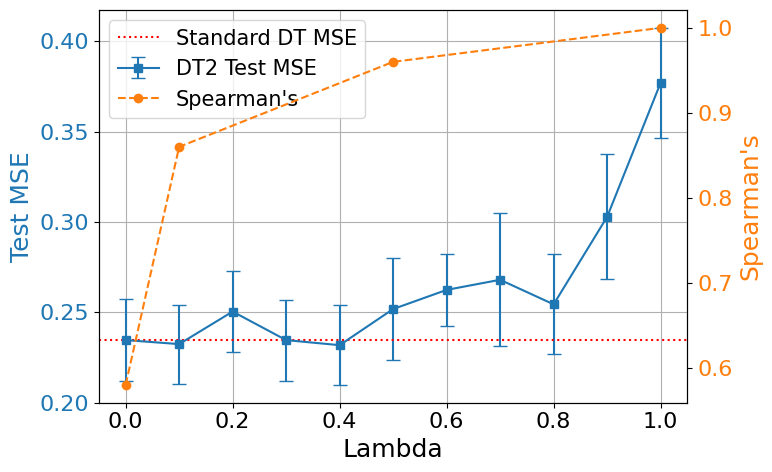

In [6]:
import matplotlib.pyplot as plt
import numpy as np

lambdas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Add supervised_test_mse as the point for lambda=0
supervised_test_mean, supervised_test_se = mean_se(supervised_test_mse)

# Compute averages and standard errors for each lambda value (excluding lambda=0)
kendall_test_means = []
kendall_test_ses = []
test_mse_list = [
    kendell_01_test_mse,
    kendell_02_test_mse,
    kendell_03_test_mse,
    kendell_04_test_mse,
    kendell_05_test_mse,
    kendell_06_test_mse,
    kendell_07_test_mse,
    kendell_08_test_mse,
    kendell_09_test_mse,
    kendell_1_test_mse,
]
for test in test_mse_list:
    mean_te, se_te = mean_se(test)
    kendall_test_means.append(mean_te)
    kendall_test_ses.append(se_te)

# Insert supervised at lambda=0
kendall_test_means = [supervised_test_mean] + kendall_test_means
kendall_test_ses = [supervised_test_se] + kendall_test_ses

# Calculate averages for supervised baselines
supervised_test_avg = np.mean(supervised_test_mse)

plt.rcParams.update({'font.size': 16})
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot MSE with error bars
ax1.errorbar(lambdas, kendall_test_means, yerr=kendall_test_ses, marker='s', label='DT2 Test MSE', capsize=5, color='tab:blue')
ax1.axhline(supervised_test_avg, color='red', linestyle=':', label='Standard DT MSE')
ax1.set_xlabel('Lambda', fontsize=18)
ax1.set_ylabel('Test MSE', color='tab:blue', fontsize=18)
ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)
ax1.grid(True)

# Spearman's axis
ax2 = ax1.twinx()
spearman_lambdas = [0.0, 0.1, 0.5, 1.0]
spearman_values = [0.58, 0.86, 0.96, 1.0]
ax2.plot(spearman_lambdas, spearman_values, 'o--', color='tab:orange', label="Spearman's")
ax2.set_ylabel("Spearman's", color='tab:orange', fontsize=18)
ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=16)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=15)

plt.tight_layout()
plt.savefig('lambda_cancer_mse.pdf')
plt.show()


# Results processing script

In [31]:
import json
import os
import numpy as np

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        
        # Explicitly handle None (JSON null)
        if val is None:
            return -np.inf
        
        # Attempt to convert to float (handles strings like "10.5")
        return float(val)
        
    except (KeyError, TypeError, ValueError):
        # KeyError: Key missing
        # TypeError: Trying to access [key] on a None object
        # ValueError: Found a string that isn't a number
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    # 1. Extract raw scores for every method for every policy
    scores = {m: [] for m in METRIC_PATHS.keys()}
    
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    # Convert to numpy arrays for easier handling
    for m in scores:
        scores[m] = np.array(scores[m])

    # 2. Determine True Best Value (Oracle)
    # Validate that we have at least one valid ground truth value
    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    # 3. Calculate Rankings and Regrets
    file_output = {
        "rankings": {},
        "regrets": {}
    }

    for method, values in scores.items():
        # If a method has all -inf (all null), argsort is arbitrary but won't crash.
        # [::-1] reverses it to descending (Best to Worst).
        ranking = np.argsort(values)[::-1]
        
        file_output["rankings"][method] = ranking.tolist()
        
        if method != "env_mc":
            # Identify which policy this method thinks is best
            selected_policy_idx = ranking[0]
            
            # If the method picked a policy that has a NULL env_mc (unlikely but possible),
            # treating it as a standard float calculation might fail if we didn't sanitize inputs.
            # But true_values is sanitized to -inf if missing.
            val_of_selected = true_values[selected_policy_idx]
            
            # Sanity check: If the true value of the selected policy is -inf (missing data),
            # the regret is infinite/undefined.
            if np.isinf(val_of_selected):
                # Regret is theoretically infinite if we picked a policy with no result
                # Here we default to a very large number or just 0.0 depending on preference.
                # Usually, we skip, but for stability, let's record nan.
                regret = np.nan 
            else:
                regret = true_optimal_val - val_of_selected
            
            file_output["regrets"][method] = float(regret)

    return file_output

def aggregate_results(seed_range, file_pattern="./test/hopper_pipeline/resnet/summary_{}.json"):
    """
    Iterates over seeds, processes files, and aggregates results into lists.
    """
    
    # Data structures to hold aggregated lists
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    
    valid_seeds = []

    print(f"Processing seeds {seed_range}...")

    for seed in seed_range:
        filename = file_pattern.format(seed)
        
        if not os.path.exists(filename):
            # print(f"Warning: File {filename} not found. Skipping.")
            continue
            
        # Process the individual file
        single_res = process_single_seed(filename)
        
        # If processing failed (e.g. env_mc was null), skip aggregation for this seed
        if single_res is None:
            continue

        valid_seeds.append(seed)
        
        # Append to aggregates
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
            
        for method in agg_regrets.keys():
            val = single_res["regrets"][method]
            # Only append if it's not NaN, or decide how you want to handle NaN regrets
            # Here we append it, and np.nanmean can handle it later if needed
            agg_regrets[method].append(val)

    return agg_rankings, agg_regrets, valid_seeds

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # Define the range of seeds you want to process
    SEEDS = list(range(0, 27))
    
    # Run aggregation
    rankings, regrets, processed_seeds = aggregate_results(SEEDS)

    if not processed_seeds:
        print("No valid files processed.")
    else:
        print("\n" + "="*30)
        print(f"AGGREGATED RESULTS ({len(processed_seeds)} seeds)")
        print("="*30)

        # 1. Output True Rankings
        print("\n--- True Rankings (env_mc) [List of Lists] ---")
        # Print first 3 to avoid clutter if list is huge
        print(str(rankings['env_mc'][:3]) + " ... (showing first 3)")

        # 2. Output OPE Rankings
        print("\n--- OPE Rankings [List of Lists] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet']:
            print(f"\nMethod: {method}")
            print(str(rankings[method][:3]) + " ...")

        # 3. Output OPE Regrets
        print("\n--- OPE Regrets [List of Floats] ---")
        for method in ['supervised', 'q_estimate', 'kendall', 'hinge', 'listnet']:
            # Use nanmean to safely calculate mean ignoring NaNs
            avg_regret = np.nanmean(regrets[method])
            
            # Count how many valid regrets we actually have
            valid_count = np.count_nonzero(~np.isnan(regrets[method]))
            
            print(f"\nMethod: {method}")
            # print(f"Values: {regrets[method]}")
            print(f"Average Regret: {avg_regret:.4f} (calculated over {valid_count} valid seeds)")

Processing seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]...

AGGREGATED RESULTS (5 seeds)

--- True Rankings (env_mc) [List of Lists] ---
[[5, 2, 4, 3, 1, 0], [5, 2, 4, 3, 1, 0], [5, 2, 4, 3, 1, 0]] ... (showing first 3)

--- OPE Rankings [List of Lists] ---

Method: supervised
[[4, 2, 3, 5, 1, 0], [4, 2, 3, 5, 1, 0], [5, 2, 3, 1, 4, 0]] ...

Method: q_estimate
[[5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: kendall
[[4, 3, 5, 2, 1, 0], [4, 3, 2, 5, 1, 0], [5, 4, 3, 2, 1, 0]] ...

Method: hinge
[[5, 4, 3, 2, 1, 0], [4, 3, 2, 5, 1, 0], [3, 4, 5, 2, 1, 0]] ...

Method: listnet
[[5, 2, 3, 4, 1, 0], [5, 3, 2, 4, 1, 0], [3, 2, 5, 4, 1, 0]] ...

--- OPE Regrets [List of Floats] ---

Method: supervised
Average Regret: 0.6893 (calculated over 5 valid seeds)

Method: q_estimate
Average Regret: 0.0000 (calculated over 5 valid seeds)

Method: kendall
Average Regret: 0.4192 (calculated over 5 valid seeds)

Method:

In [3]:
import numpy as np
from scipy import stats

def analyze_performance(rankings, regrets):
    """
    Calculates Average Regret (+- SE), Spearman's Correlation (+- SE),
    and Pass@1 (+- SE).
    
    Args:
        rankings (dict): Dictionary of lists of lists.
        regrets (dict): Dictionary of lists of floats.
    """
    
    # Helper to calculate Mean and Standard Error
    def get_stats(data):
        if not data:
            return 0.0, 0.0
        data = np.array(data)
        mean = np.mean(data)
        # ddof=1 for sample standard deviation
        se = np.std(data, ddof=1) / np.sqrt(len(data)) 
        return mean, se

    # Helper to convert "sorted indices" into a "rank vector"
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    # Adjusted column widths for the new metric
    print(f"{'METHOD':<15} | {'AVG REGRET':<18} | {'AVG SPEARMAN':<18} | {'PASS@1 (%)':<18}")
    print("-" * 75)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    
    for method in methods:
        method_rankings = rankings[method]
        
        # 1. Regret Statistics
        method_regrets = regrets[method]
        reg_mean, reg_se = get_stats(method_regrets)
        
        # 2. Spearman & Pass@1 Statistics
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, method_rankings):
            # --- Spearman Calculation ---
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            
            # --- Pass@1 Calculation ---
            # Compare the first element (index 0) of both sorted lists
            # 1.0 if they identify the same best policy, 0.0 otherwise
            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
            
        corr_mean, corr_se = get_stats(spearman_scores)
        p1_mean, p1_se = get_stats(pass1_scores)
        
        # Convert Pass@1 to percentage
        p1_mean_pct = p1_mean * 100
        p1_se_pct = p1_se * 100
        
        # 3. Print Row
        reg_str = f"{reg_mean:.2f} ± {reg_se:.2f}"
        corr_str = f"{corr_mean:.3f} ± {corr_se:.3f}"
        p1_str = f"{p1_mean_pct:.1f}% ± {p1_se_pct:.1f}%"
        
        print(f"{method:<15} | {reg_str:<18} | {corr_str:<18} | {p1_str:<18}")

# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Assuming 'rankings' and 'regrets' are already computed 
    # via the aggregate_results function from the previous script
    
    print("\n" + "="*30)
    print("STATISTICAL ANALYSIS")
    print("="*30)
    
    analyze_performance(rankings, regrets)


STATISTICAL ANALYSIS
METHOD          | AVG REGRET         | AVG SPEARMAN       | PASS@1 (%)        
---------------------------------------------------------------------------
q_estimate      | 0.00 ± 0.00        | 0.829 ± 0.000      | 100.0% ± 0.0%     
supervised      | 1.61 ± 0.44        | 0.491 ± 0.086      | 0.0% ± 0.0%       
kendall         | 0.67 ± 0.17        | 0.623 ± 0.046      | 30.0% ± 15.3%     
hinge           | 0.73 ± 0.12        | 0.577 ± 0.087      | 10.0% ± 10.0%     
listnet         | 0.67 ± 0.20        | 0.554 ± 0.077      | 40.0% ± 16.3%     


In [293]:
from scipy import stats
import numpy as np

def bootstrap_ci(data, n_boot=10000, ci=95, rng=None):
    """
    Returns mean and percentile bootstrap CI.
    """
    if len(data) == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)
    data = np.asarray(data)
    n = len(data)

    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_means[i] = np.mean(sample)

    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)

    return np.mean(data), (lower, upper)

def analyze_performance_bootstrap(rankings, regrets, n_boot=10000):
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    print(f"{'METHOD':<15} | {'AVG REGRET':<28} | {'AVG SPEARMAN':<28} | {'PASS@1 (%)':<28}")
    print("-" * 95)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())

    for method in methods:
        # --- Regret ---
        reg_mean, reg_ci = bootstrap_ci(regrets[method], n_boot=n_boot)
        reg_str = f"{reg_mean:.2f} [{reg_ci[0]:.2f}, {reg_ci[1]:.2f}]"

        # --- Spearman + Pass@1 ---
        spearman_scores = []
        pass1_scores = []

        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)

            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)

            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)

        corr_mean, corr_ci = bootstrap_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bootstrap_ci(pass1_scores, n_boot=n_boot)

        corr_str = f"{corr_mean:.3f} [{corr_ci[0]:.3f}, {corr_ci[1]:.3f}]"
        p1_str = f"{100*p1_mean:.1f}% [{100*p1_ci[0]:.1f}, {100*p1_ci[1]:.1f}]"

        print(f"{method:<15} | {reg_str:<28} | {corr_str:<28} | {p1_str:<28}")

analyze_performance_bootstrap(rankings, regrets, n_boot=10000)


METHOD          | AVG REGRET                   | AVG SPEARMAN                 | PASS@1 (%)                  
-----------------------------------------------------------------------------------------------


q_estimate      | 0.00 [0.00, 0.00]            | 0.943 [0.943, 0.943]         | 100.0% [100.0, 100.0]       
supervised      | 1.75 [0.34, 3.15]            | 0.509 [0.463, 0.554]         | 0.0% [0.0, 0.0]             
kendall         | 1.30 [0.08, 2.79]            | 0.543 [0.371, 0.760]         | 20.0% [0.0, 60.0]           
hinge           | 0.48 [0.00, 1.40]            | 0.703 [0.531, 0.817]         | 60.0% [20.0, 100.0]         
listnet         | 2.66 [0.70, 5.84]            | 0.623 [0.360, 0.817]         | 0.0% [0.0, 0.0]             


In [294]:
import numpy as np
from scipy.stats import norm

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

from scipy import stats

def analyze_performance_bca(rankings, regrets, n_boot=10000):
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    print(f"{'METHOD':<15} | {'AVG REGRET':<28} | {'AVG SPEARMAN':<28} | {'PASS@1 (%)':<28}")
    print("-" * 95)

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())

    for method in methods:
        # --- Regret ---
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot)
        reg_str = f"{reg_mean:.2f} [{reg_ci[0]:.2f}, {reg_ci[1]:.2f}]"

        # --- Spearman + Pass@1 ---
        spearman_scores = []
        pass1_scores = []

        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)

            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)

            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)

        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)

        corr_str = f"{corr_mean:.3f} [{corr_ci[0]:.3f}, {corr_ci[1]:.3f}]"
        p1_str = f"{100*p1_mean:.1f}% [{100*p1_ci[0]:.1f}, {100*p1_ci[1]:.1f}]"

        print(f"{method:<15} | {reg_str:<28} | {corr_str:<28} | {p1_str:<28}")

analyze_performance_bca(rankings, regrets, n_boot=10000)

METHOD          | AVG REGRET                   | AVG SPEARMAN                 | PASS@1 (%)                  
-----------------------------------------------------------------------------------------------
q_estimate      | 0.00 [0.00, 0.00]            | 0.943 [0.943, 0.943]         | 100.0% [100.0, 100.0]       
supervised      | 1.75 [0.53, 2.98]            | 0.509 [0.463, 0.554]         | 0.0% [0.0, 0.0]             
kendall         | 1.30 [0.11, 2.51]            | 0.543 [0.406, 0.737]         | 20.0% [0.0, 40.0]           
hinge           | 0.48 [0.00, 1.37]            | 0.703 [0.509, 0.794]         | 60.0% [0.0, 80.0]           
listnet         | 2.66 [0.88, 6.03]            | 0.623 [0.349, 0.760]         | 0.0% [0.0, 0.0]             


Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


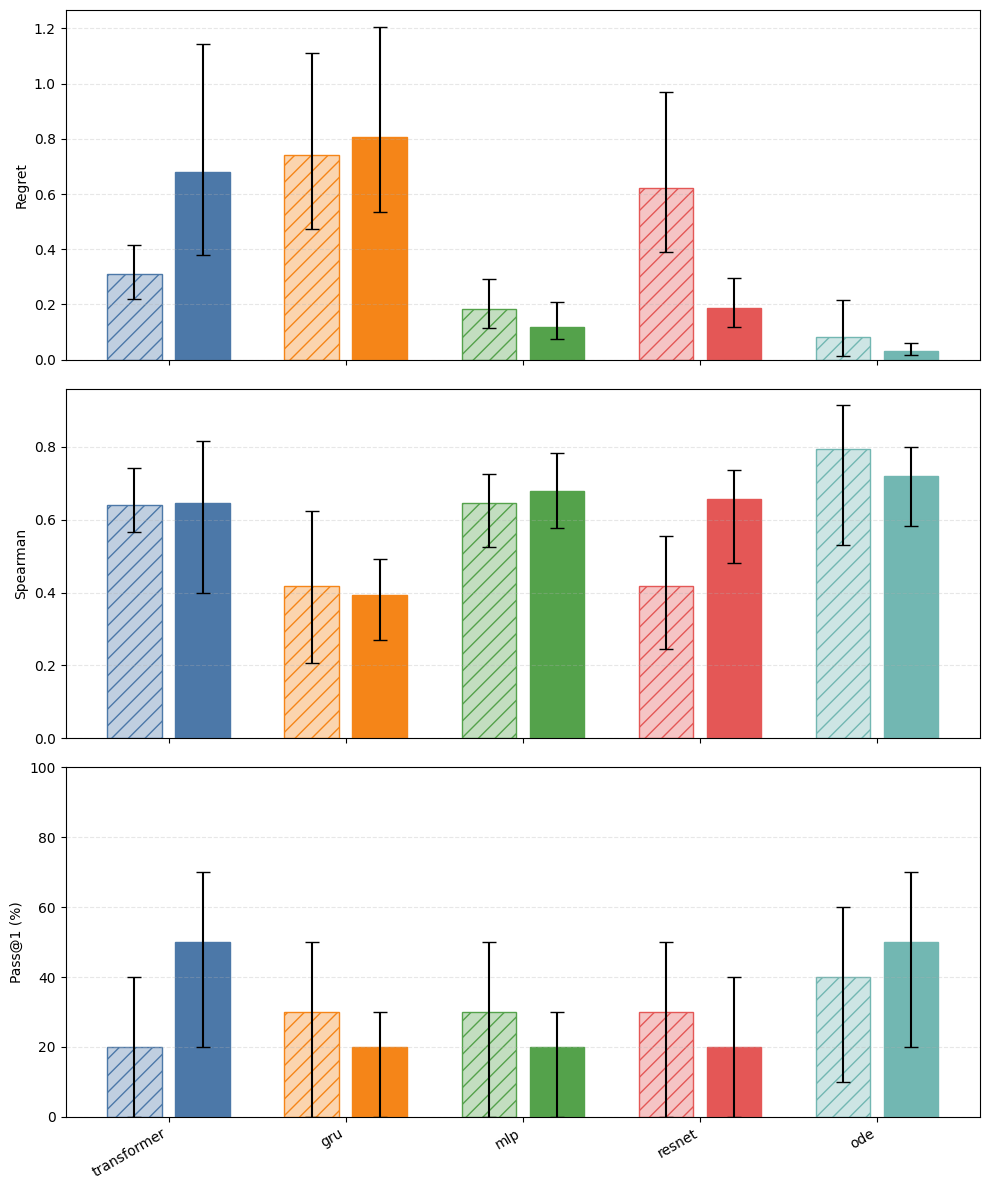

In [ ]:
#graphing pane

import json
import os
import numpy as np
from scipy.stats import norm

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/pendulum_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(0, 10))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=70)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

Processing transformer seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


Processing gru seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing mlp seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing resnet seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...
Processing ode seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]...


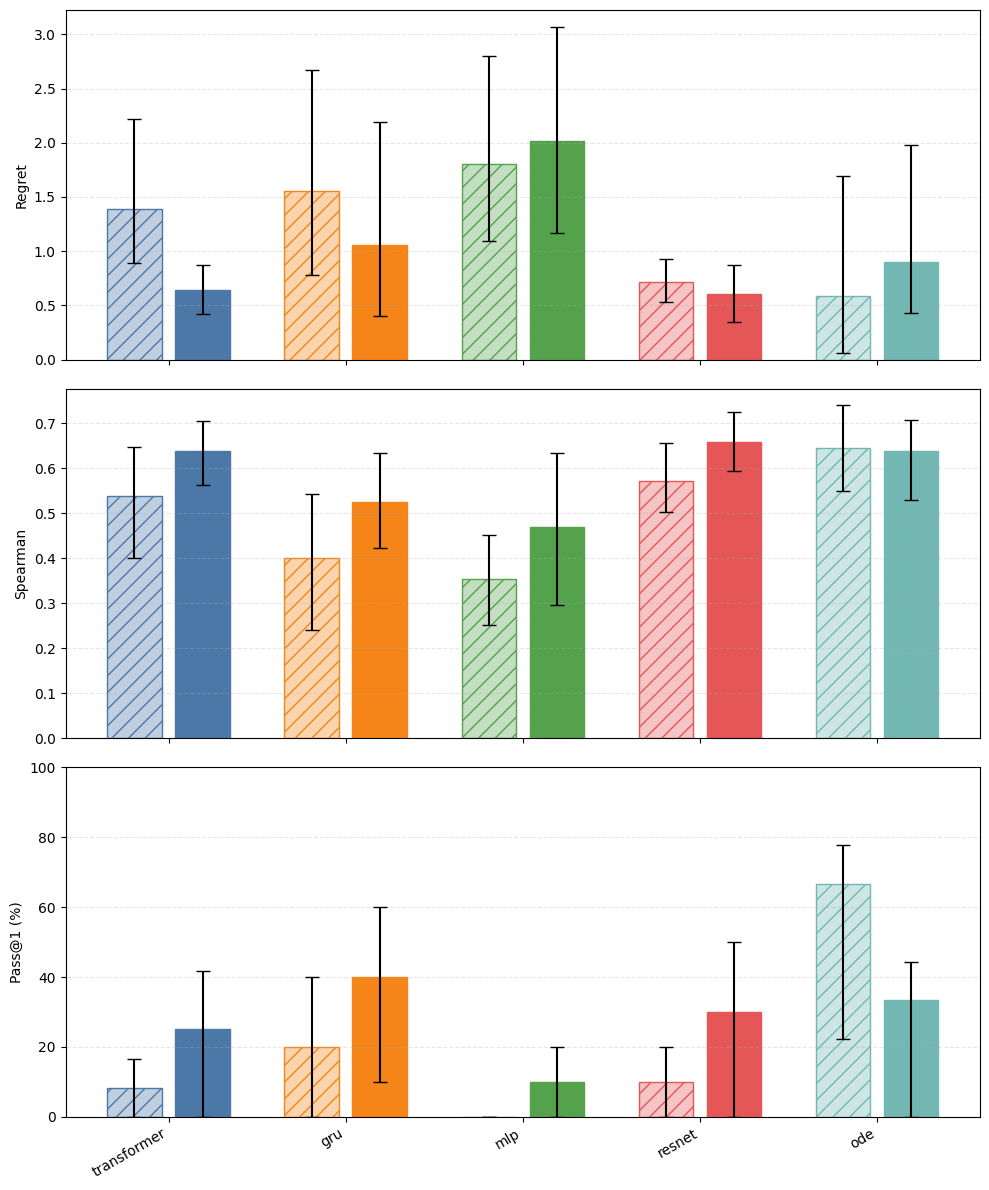

In [6]:
#graphing pane

import json
import os
import numpy as np
from scipy.stats import norm

def bca_ci(data, stat_fn=np.mean, n_boot=10000, ci=90, rng=None):
    """
    BCa bootstrap confidence interval for a statistic.

    Args:
        data (array-like): sample (e.g., seed-level results)
        stat_fn (callable): statistic to bootstrap (default: mean)
        n_boot (int): number of bootstrap resamples
        ci (float): confidence level (e.g., 95)
    """
    data = np.asarray(data)
    n = len(data)

    if n == 0:
        return 0.0, (0.0, 0.0)

    rng = np.random.default_rng(rng)

    # Original statistic
    theta_hat = stat_fn(data)

    # --- Bootstrap distribution ---
    boot_stats = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        boot_stats[i] = stat_fn(sample)

    # --- Bias correction z0 ---
    prop_less = np.mean(boot_stats < theta_hat)
    z0 = norm.ppf(prop_less if prop_less > 0 else 1e-10)

    # --- Acceleration via jackknife ---
    jack_stats = np.empty(n)
    for i in range(n):
        jack_sample = np.delete(data, i)
        jack_stats[i] = stat_fn(jack_sample)

    jack_mean = np.mean(jack_stats)
    num = np.sum((jack_mean - jack_stats) ** 3)
    den = 6.0 * (np.sum((jack_mean - jack_stats) ** 2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # --- Adjusted quantiles ---
    alpha = (100 - ci) / 100 / 2
    z_low = norm.ppf(alpha)
    z_high = norm.ppf(1 - alpha)

    def adj_alpha(z):
        return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = np.percentile(boot_stats, 100 * adj_alpha(z_low))
    hi = np.percentile(boot_stats, 100 * adj_alpha(z_high))

    return theta_hat, (lo, hi)

# Configuration: Define the hierarchy of keys to find specific scores
METRIC_PATHS = {
    "env_mc": ["env_mc"],
    "q_estimate": ["q_estimate"],
    "supervised": ["dynamics", "supervised"],
    "kendall": ["dynamics", "ranking_new", "kendall"],
    "hinge": ["dynamics", "ranking_new", "hinge"],
    "listnet": ["dynamics", "ranking_new", "listnet"]
}

def get_nested_value(dictionary, keys):
    """
    Helper to retrieve value from nested dict using a list of keys.
    Handles missing keys, None values, and non-numeric types by returning -infinity.
    """
    val = dictionary
    try:
        for key in keys:
            if val is None:
                return -np.inf
            val = val[key]
        if val is None:
            return -np.inf
        return float(val)
    except (KeyError, TypeError, ValueError):
        return -np.inf

def process_single_seed(file_path):
    """Parses a single JSON file and calculates rankings and regrets."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON in {file_path}")
        return None
    
    results = data.get("results", [])
    if not results:
        return None
    
    scores = {m: [] for m in METRIC_PATHS.keys()}
    for entry in results:
        for method, path in METRIC_PATHS.items():
            val = get_nested_value(entry, path)
            scores[method].append(val)

    for m in scores:
        scores[m] = np.array(scores[m])

    if np.all(np.isinf(scores["env_mc"])):
        print(f"Skipping {file_path}: 'env_mc' contains only Null/Invalid values.")
        return None

    true_values = scores["env_mc"]
    true_optimal_idx = np.argmax(true_values)
    true_optimal_val = true_values[true_optimal_idx]

    file_output = {"rankings": {}, "regrets": {}}
    for method, values in scores.items():
        ranking = np.argsort(values)[::-1]
        file_output["rankings"][method] = ranking.tolist()
        if method != "env_mc":
            selected_policy_idx = ranking[0]
            val_of_selected = true_values[selected_policy_idx]
            regret = np.nan if np.isinf(val_of_selected) else true_optimal_val - val_of_selected
            file_output["regrets"][method] = float(regret)
    return file_output

def aggregate_results(seed_range, folder):
    """Iterates over seeds for a folder, processes files, and aggregates results."""
    pattern = f"./test/hopper_pipeline/{folder}/summary_{{}}.json"
    agg_rankings = {m: [] for m in METRIC_PATHS.keys()}
    agg_regrets = {m: [] for m in METRIC_PATHS.keys() if m != "env_mc"}
    valid_seeds = []
    print(f"Processing {folder} seeds {seed_range}...")
    for seed in seed_range:
        filename = pattern.format(seed)
        if not os.path.exists(filename):
            continue
        single_res = process_single_seed(filename)
        if single_res is None:
            continue
        valid_seeds.append(seed)
        for method in agg_rankings.keys():
            agg_rankings[method].append(single_res["rankings"][method])
        for method in agg_regrets.keys():
            agg_regrets[method].append(single_res["regrets"][method])
    return agg_rankings, agg_regrets, valid_seeds

SEEDS = list(range(0, 30))

def collect_performance_bca(rankings, regrets, n_boot=10000):
    results = {}

    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        r = np.zeros(n)
        for rank, idx in enumerate(sorted_indices):
            r[idx] = rank
        return r

    true_rankings = rankings.get("env_mc", [])
    methods = list(regrets.keys())
    methods = ["supervised", "kendall"]
    for method in methods:
        reg_mean, reg_ci = bca_ci(regrets[method], n_boot=n_boot, ci=90)
        spearman_scores = []
        pass1_scores = []
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            pass1_scores.append(1.0 if true_sort[0] == method_sort[0] else 0.0)
        corr_mean, corr_ci = bca_ci(spearman_scores, n_boot=n_boot)
        p1_mean, p1_ci = bca_ci(pass1_scores, n_boot=n_boot)
        results[method] = {
            "regret": (reg_mean, reg_ci),
            "spearman": (corr_mean, corr_ci),
            "pass1": (p1_mean * 100, (p1_ci[0] * 100, p1_ci[1] * 100)),
        }
    return results

# Compute and plot for each model folder
MODEL_FOLDERS = ["transformer", "gru", "mlp", "resnet", "ode"]
metrics = [("regret", "Regret"), ("spearman", "Spearman"), ("pass1", "Pass@1 (%)")]

results_by_folder = {}
for folder in MODEL_FOLDERS:
    rankings, regrets, processed_seeds = aggregate_results(SEEDS, folder)
    if not processed_seeds:
        print(f"No valid seeds for {folder}; skipping.")
        continue
    results_by_folder[folder] = collect_performance_bca(rankings, regrets)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

methods = ["supervised", "kendall"]
folders = list(results_by_folder.keys())

if not folders:
    print("No results to plot.")
else:
    group_gap = 0.6
    group_size = len(methods)
    positions = []
    for i, folder in enumerate(folders):
        base = i * (group_size + group_gap)
        for j in range(group_size):
            positions.append(base + j)
    centers = [i * (group_size + group_gap) + (group_size - 1) / 2 for i in range(len(folders))]
    palette = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA7"]
    folder_colors = {folder: palette[i % len(palette)] for i, folder in enumerate(folders)}
    hatch_map = {"supervised": "//", "kendall": None}
    face_colors = []
    edge_colors = []
    hatches = []
    for folder in folders:
        base_color = folder_colors[folder]
        for m in methods:
            if m == "supervised":
                face_colors.append(mcolors.to_rgba(base_color, alpha=0.35))
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])
            else:
                face_colors.append(base_color)
                edge_colors.append(base_color)
                hatches.append(hatch_map[m])

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(max(8, 2 * len(folders)), 12), sharex=True)

    for ax, (metric, label) in zip(axes, metrics):
        means = []
        lowers = []
        uppers = []
        for folder in folders:
            res = results_by_folder[folder]
            for m in methods:
                if m not in res:
                    means.append(np.nan)
                    lowers.append(np.nan)
                    uppers.append(np.nan)
                    continue
                mean, ci = res[m][metric]
                means.append(mean)
                lowers.append(mean - ci[0])
                uppers.append(ci[1] - mean)
        for pos, mean, lo, up, fc, ec, hatch in zip(positions, means, lowers, uppers, face_colors, edge_colors, hatches):
            ax.bar(pos, mean, yerr=[[lo], [up]], capsize=5, color=[fc], edgecolor=ec, hatch=hatch, linewidth=1)
        ax.set_ylabel(label)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        if metric == "pass1":
            ax.set_ylim(0, 100)

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(folders, rotation=30, ha="right")

    folder_handles = [Patch(facecolor=folder_colors[f], edgecolor=folder_colors[f], label=f) for f in folders]
    method_handles = [
        Patch(facecolor=mcolors.to_rgba("black", 0.0), edgecolor="black", hatch=hatch_map["supervised"], label="Supervised", linewidth=1),
        Patch(facecolor=mcolors.to_rgba("black", 1.0), edgecolor="black", label="Kendall", linewidth=1),
    ]

    fig.tight_layout()
    plt.show()

In [258]:
import numpy as np
from scipy import stats

def generate_latex_table(rankings, regrets, env_name="LunarLander (NLL base)"):
    """
    Generates a LaTeX table string with Mean (SE) and bolding for best methods.
    
    Args:
        rankings (dict): Dictionary of lists of lists (rankings).
        regrets (dict): Dictionary of lists of floats (regrets).
        env_name (str): The name of the environment for the first column.
    """
    
    # --- 1. CONFIGURATION & HELPER FUNCTIONS ---
    
    # Map internal keys to nice LaTeX names
    METHOD_NAMES = {
        "supervised": "DT",
        "q_estimate": "FQE",
        "kendall": "$DT^2$",
        "hinge": "Hinge",
        "listnet": "ListNet"
    }
    
    # Define methods list (excluding env_mc)
    methods = [m for m in rankings.keys() if m not in ["env_mc", "q_estimate"]]
    
    # Helper: Get Mean and SE
    def get_stats(data):
        if not data: return 0.0, 0.0
        arr = np.array(data)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        return mean, se

    # Helper: Convert sorted indices to rank vector (for Spearman)
    def to_rank_vector(sorted_indices):
        n = len(sorted_indices)
        rank_vec = np.zeros(n)
        for rank, policy_idx in enumerate(sorted_indices):
            rank_vec[policy_idx] = rank
        return rank_vec

    # --- 2. CALCULATE STATISTICS FOR ALL METHODS ---
    
    stats_data = {} # Stores {method: {metric: (mean, se)}}
    true_rankings = rankings.get("env_mc", [])
    num_seeds = len(true_rankings)

    for method in methods:
        method_stats = {}
        
        # A. Regret
        r_mean, r_se = get_stats(regrets[method])
        method_stats['regret'] = (r_mean, r_se)
        
        # B. Spearman & Pass@1
        spearman_scores = []
        pass1_scores = []
        
        for true_sort, method_sort in zip(true_rankings, rankings[method]):
            # Spearman
            r_true = to_rank_vector(true_sort)
            r_method = to_rank_vector(method_sort)
            corr, _ = stats.spearmanr(r_true, r_method)
            spearman_scores.append(corr)
            
            # Pass@1 (1.0 if match, 0.0 if not)
            is_match = 1.0 if true_sort[0] == method_sort[0] else 0.0
            pass1_scores.append(is_match)
            
        s_mean, s_se = get_stats(spearman_scores)
        method_stats['spearman'] = (s_mean, s_se)
        
        p_mean, p_se = get_stats(pass1_scores)
        # Convert Pass@1 to percentage (0-100) for the table
        method_stats['pass1'] = (p_mean * 100, p_se * 100)
        
        stats_data[method] = method_stats

    # --- 3. IDENTIFY BEST METHODS (FOR BOLDING) ---
    
    metrics = ['spearman', 'pass1', 'regret']
    best_methods = {m: [] for m in metrics} # List of method keys that should be bold

    for metric in metrics:
        # 1. Find the "Outright Best" value
        # Spearman/Pass1 -> Maximize. Regret -> Minimize.
        means = [stats_data[m][metric][0] for m in methods]
        
        if metric == 'regret':
            best_val = min(means)
            best_idx = np.argmin(means)
        else:
            best_val = max(means)
            best_idx = np.argmax(means)
            
        # Get the interval of the outright best: [mean - se, mean + se]
        best_method_key = methods[best_idx]
        best_mean, best_se = stats_data[best_method_key][metric]
        best_interval = (best_mean - best_se, best_mean + best_se)

        # 2. Check Overlap for all other methods
        for method in methods:
            curr_mean, curr_se = stats_data[method][metric]
            curr_interval = (curr_mean - curr_se, curr_mean + curr_se)
            
            # Check intersection
            # Logic: Interval A overlaps Interval B if max(start_A, start_B) <= min(end_A, end_B)
            overlap = max(best_interval[0], curr_interval[0]) <= min(best_interval[1], curr_interval[1])
            
            if overlap:
                best_methods[metric].append(method)

    # --- 4. BUILD LATEX STRING ---
    
    print(r"\begin{table}[th]")
    print(r"    \centering")
    print(f"    \\caption{{Average results over ${num_seeds}$ seeds, reported with standard errors. Best performing methods (overlapping intervals with the outright best) in bold.}}")
    print(r"    \begin{tabular}{c c c c c}")
    print(r"    \toprule")
    print(r"        Environment &  Method & Spearman ($\uparrow$) & Pass@1 \% ($\uparrow$) & Regret@1 ($\downarrow$)\\")
    print(r"    \midrule")
    
    for i, method in enumerate(methods):
        # Determine pretty name
        pretty_name = METHOD_NAMES.get(method, method)
        
        # Prepare row strings
        row_str = ""
        
        # 1. Environment Column (Multirow for first entry)
        if i == 0:
            row_str += f"        \\multirow{{{len(methods)}}}{{*}}{{\\texttt{{{env_name}}}}} & "
        else:
            row_str += "        & "
            
        row_str += f"{pretty_name} & "
        
        # 2. Metrics Columns
        for j, metric in enumerate(['spearman', 'pass1', 'regret']):
            mean, se = stats_data[method][metric]
            
            # Formatting: 2 decimal places usually
            # Special case: Pass@1 might look better with 1 decimal if it's 0-100
            fmt = "{:.2f}"
            if metric == 'pass1': fmt = "{:.1f}" 
            
            val_str = fmt.format(mean)
            se_str = fmt.format(se)
            
            # Apply Bold if in best_methods
            if method in best_methods[metric]:
                cell = f"\\textbf{{{val_str}}}\\,{{\\scriptsize({se_str})}}"
            else:
                cell = f"{val_str}\\,{{\\scriptsize({se_str})}}"
            
            row_str += cell
            if j < 2: row_str += " & "
            
        row_str += "\\\\" # End of row
        print(row_str)

    print(r"    \bottomrule")
    print(r"    \end{tabular}")
    print(r"\end{table}")

# ==========================================
# EXAMPLE USAGE
# ==========================================
if __name__ == "__main__":
    # Assuming 'rankings' and 'regrets' are populated from previous steps
    print("\n--- LATEX TABLE OUTPUT ---\n")
    generate_latex_table(rankings, regrets, env_name="LunarLander (NLL)")


--- LATEX TABLE OUTPUT ---

\begin{table}[th]
    \centering
    \caption{Average results over $9$ seeds, reported with standard errors. Best performing methods (overlapping intervals with the outright best) in bold.}
    \begin{tabular}{c c c c c}
    \toprule
        Environment &  Method & Spearman ($\uparrow$) & Pass@1 \% ($\uparrow$) & Regret@1 ($\downarrow$)\\
    \midrule
        \multirow{4}{*}{\texttt{LunarLander (NLL)}} & DT & \textbf{0.64}\,{\scriptsize(0.06)} & \textbf{22.2}\,{\scriptsize(14.7)} & \textbf{0.27}\,{\scriptsize(0.10)}\\
        & $DT^2$ & \textbf{0.61}\,{\scriptsize(0.14)} & \textbf{44.4}\,{\scriptsize(17.6)} & \textbf{0.76}\,{\scriptsize(0.39)}\\
        & Hinge & \textbf{0.52}\,{\scriptsize(0.13)} & 0.0\,{\scriptsize(0.0)} & \textbf{5.09}\,{\scriptsize(4.92)}\\
        & ListNet & -0.21\,{\scriptsize(0.27)} & 11.1\,{\scriptsize(11.1)} & 20.47\,{\scriptsize(7.75)}\\
    \bottomrule
    \end{tabular}
\end{table}


# OGBench tests

In [60]:
import ogbench

dataset_name = 'pointmaze-medium-navigate-singletask-v0'
env, train_dataset, val_dataset = ogbench.make_env_and_datasets(dataset_name)

In [61]:
train_dataset

{'observations': array([[12.429421 , 12.568156 ],
        [12.443868 , 12.768156 ],
        [12.531055 , 12.968156 ],
        ...,
        [ 4.1317916,  4.634845 ],
        [ 3.9317915,  4.8348446],
        [ 4.0947647,  4.899703 ]], dtype=float32),
 'actions': array([[ 0.07223146,  1.        ],
        [ 0.43593547,  1.        ],
        [-0.6769872 ,  0.48066953],
        ...,
        [-1.        ,  1.        ],
        [ 0.8148661 ,  0.3242916 ],
        [ 0.2560587 ,  0.3138587 ]], dtype=float32),
 'terminals': array([0., 0., 0., ..., 0., 0., 1.], dtype=float32),
 'next_observations': array([[12.443868 , 12.768156 ],
        [12.531055 , 12.968156 ],
        [12.395658 , 13.06429  ],
        ...,
        [ 3.9317915,  4.8348446],
        [ 4.0947647,  4.899703 ],
        [ 4.1459765,  4.962475 ]], dtype=float32),
 'rewards': array([-1., -1., -1., ..., -1., -1., -1.], dtype=float32),
 'masks': array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)}